# Decoding Model Stim1

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import pickle as pk
from sklearn.decomposition import PCA
import torch

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
# import model
from model import generate_input_stim_xor, eval_tf

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import trajectory_utils as tu
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/trajectory/fixed_pt/')
import load_RNN_model as lrm
from run_RNN_search import get_period_pca

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-03-20 10:45:31.453947: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-20 10:45:31.462619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-20 10:45:31.471976: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register facto

Instructions for updating:
non-resource variables are not supported in the long term


## Decode stim1 identity from delay period

### decode using entire delay period

In [2]:
importlib.reload(tu)

models_types = ['good_models','bad_models','lesion_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

all_accs= []
for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located

    if models_type == 'lesion_models':
        models_type = 'good_models'
        lesion = 'ii'
        lesion_flag = f'_lesion{lesion}'
    else:
        lesion = ''
        lesion_flag = ''

        
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    acc = np.zeros(len(model_list))
    for i_model in range(len(model_list)):
        RNN_model_file = model_list[i_model]
        model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
        rnn_path = os.path.join(models_dir, RNN_model_file) 
        model_path = os.path.join(models_dir, RNN_model_file)
        model = scipy.io.loadmat(model_path)

        # get X for this model, and restrict to delay period
        xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX{lesion_flag}.npy')
        times = np.arange(settings['stim_on']+settings['stim_dur'],settings['stim_on']+settings['stim_dur']+settings['delay']) # Maintenance
        delay_xx_trials = np.mean(xx_trials[:,times,:], axis=1)

        trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels{lesion_flag}.npy')
        decode_labels = trial_stim_labels[:,0]

        # split trials into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(delay_xx_trials, decode_labels, test_size=0.2, random_state=42)

        # train SVM
        clf = SVC(kernel='rbf')
        clf.fit(X_train, y_train)

        # test SVM
        y_pred = clf.predict(X_test)
        acc[i_model] = np.mean(y_pred == y_test)

    all_accs.append(acc)
    



Analyzing good_models
Analyzing bad_models
Analyzing lesion_models


Text(0, 0.5, 'Trials')

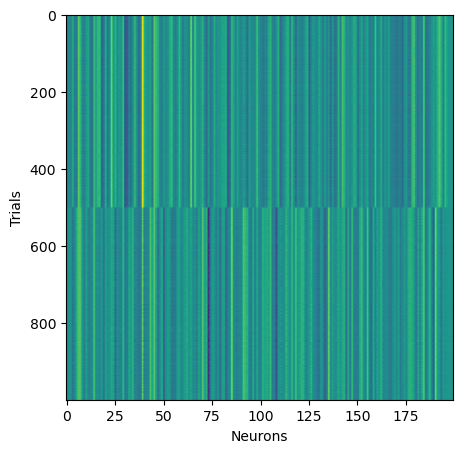

In [6]:
# plot XX_trials

fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.imshow(delay_xx_trials, aspect='auto', cmap='viridis')
ax.set_xlabel('Neurons')
ax.set_ylabel('Trials')

In [6]:
# print length of accs

print(len(all_accs[0]))
print(len(all_accs[1]))

41
26


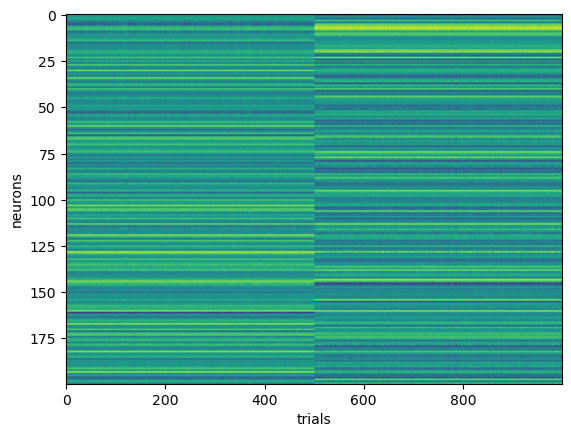

In [41]:
plt.imshow(delay_xx_trials.T, aspect='auto')
plt.xlabel('trials')
plt.ylabel('neurons');

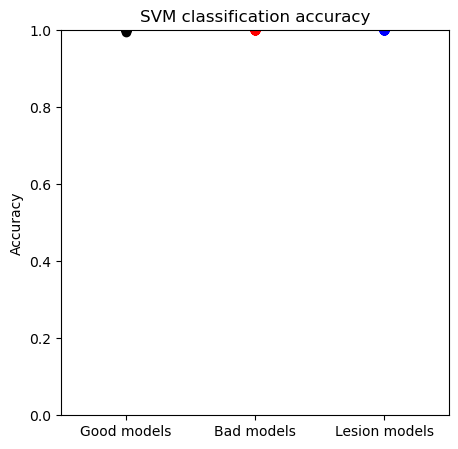

In [3]:
# plot results

plt.figure(figsize=(5,5))
plt.scatter(np.zeros(len(all_accs[0])), all_accs[0], color='black')
plt.scatter(np.ones(len(all_accs[1])), all_accs[1], color='red')
plt.scatter(2*np.ones(len(all_accs[2])), all_accs[2], color='blue')
plt.xticks([0,1,2], ['Good models', 'Bad models', 'Lesion models'])
# plt.xticks([0,1], ['Good models', 'Bad models'])
plt.ylim([0,1])
plt.xlim([-0.5,2.5])
plt.ylabel('Accuracy')
plt.title('SVM classification accuracy')
plt.show()

### decode using first half and second half of delay period

In [8]:
# try for first and second half of delay period


importlib.reload(tu)

models_types = ['good_models','bad_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

all_accs= []
for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    times = np.arange(settings['stim_on']+settings['stim_dur'],settings['stim_on']+settings['stim_dur']+settings['delay']) # Maintenance
    first_half = times[:len(times)//2]
    second_half = times[len(times)//2:]

    accs_half = np.zeros((len(model_list),2))
    for i_half, delay_idxs in enumerate([first_half, second_half]):
        for i_model in range(len(model_list)):
            RNN_model_file = model_list[i_model]
            model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
            rnn_path = os.path.join(models_dir, RNN_model_file) 
            model_path = os.path.join(models_dir, RNN_model_file)
            model = scipy.io.loadmat(model_path)

            # get X for this model, and restrict to delay period
            xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
            delay_xx_trials = np.mean(xx_trials[:,delay_idxs,:], axis=1)

            trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')
            decode_labels = trial_stim_labels[:,0]

            # split trials into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(delay_xx_trials, decode_labels, test_size=0.2, random_state=42)

            # train SVM
            clf = SVC(kernel='rbf')
            clf.fit(X_train, y_train)

            # test SVM
            y_pred = clf.predict(X_test)
            accs_half[i_model,i_half] = np.mean(y_pred == y_test)

    all_accs.append(accs_half)

print(all_accs[0].shape)
print(all_accs[1].shape)




Analyzing good_models
Analyzing bad_models
(41, 2)
(26, 2)


In [19]:
xx_trials.shape

(1000, 500, 200)

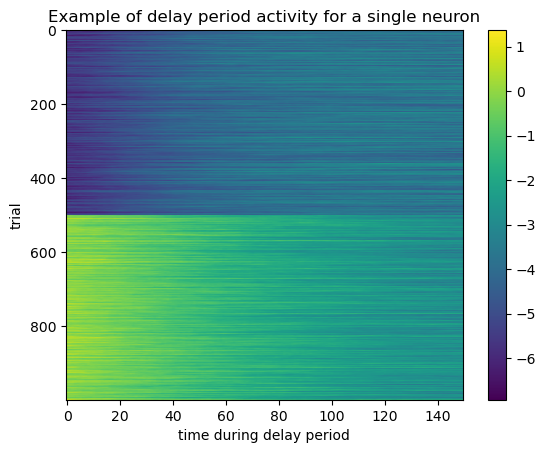

In [23]:
plt.imshow(xx_trials[:,times,0], aspect='auto')
plt.xlabel('time during delay period')
plt.ylabel('trial')
plt.title('Example of delay period activity for a single neuron')
plt.colorbar()
plt.show()

(-0.5, 3.5)

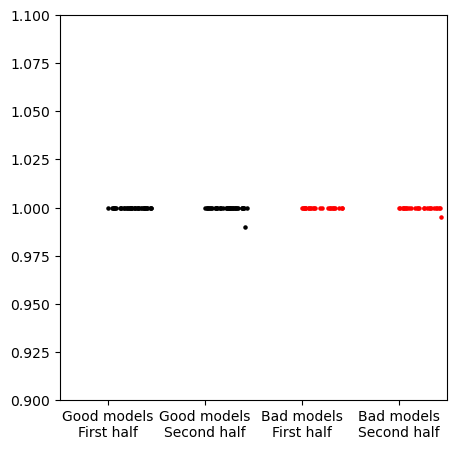

In [17]:
# plot results as scatter plot with jitter

plt.figure(figsize=(5,5))
plt.scatter(np.zeros(len(all_accs[0])) + np.random.uniform(0,0.45, len(all_accs[0])), all_accs[0][:,0], 
            s = 5, color='black')
plt.scatter(np.ones(len(all_accs[1]))*2  + np.random.uniform(0,0.45, len(all_accs[1])), all_accs[1][:,0], 
            s = 5, color='red')
plt.scatter(np.ones(len(all_accs[0])) + np.random.uniform(0,0.45, len(all_accs[0])), all_accs[0][:,1], 
            s = 5, color='black')
plt.scatter(np.ones(len(all_accs[1]))*3 +  + np.random.uniform(0,0.45, len(all_accs[1])), all_accs[1][:,1], 
            s = 5, color='red')
plt.xticks([0,1,2,3], ['Good models\nFirst half', 'Good models\nSecond half', 'Bad models\nFirst half', 'Bad models\nSecond half'])
plt.ylim([0.9,1.1])
plt.xlim([-0.5,3.5])

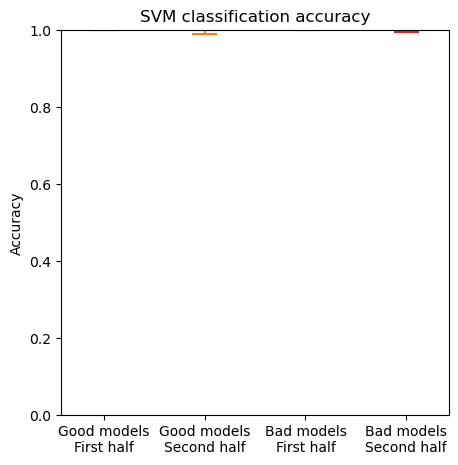

In [9]:
# plot results as violin plots

plt.figure(figsize=(5,5))
plt.violinplot(all_accs[0][:,0], positions=[0], widths=0.5)
plt.violinplot(all_accs[0][:,1], positions=[1], widths=0.5)
plt.violinplot(all_accs[1][:,0], positions=[2], widths=0.5)
plt.violinplot(all_accs[1][:,1], positions=[3], widths=0.5)
plt.xticks([0,1,2,3], ['Good models\nFirst half', 'Good models\nSecond half', 'Bad models\nFirst half', 'Bad models\nSecond half'])
plt.ylim([0,1])
plt.ylabel('Accuracy')
plt.title('SVM classification accuracy')
plt.show()


### decode, splitting up delay period into fourths

In [29]:
# continue splitting up the delay period

importlib.reload(tu)

models_types = ['good_models','bad_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

n_delay_splits = 4
all_accs = []

for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    times = np.arange(settings['stim_on']+settings['stim_dur'],settings['stim_on']+settings['stim_dur']+settings['delay']) # Maintenance
    delay_splits = np.array_split(times, n_delay_splits)

    accs_splits = np.zeros((len(model_list),len(delay_splits)))
    for i_split, delay_idxs in enumerate(delay_splits):
        for i_model in range(len(model_list)):
            RNN_model_file = model_list[i_model]
            model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
            rnn_path = os.path.join(models_dir, RNN_model_file) 
            model_path = os.path.join(models_dir, RNN_model_file)
            model = scipy.io.loadmat(model_path)

            # get X for this model, and restrict to delay period
            xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
            delay_xx_trials = np.mean(xx_trials[:,delay_idxs,:], axis=1)

            trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')
            decode_labels = trial_stim_labels[:,0]

            # split trials into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(delay_xx_trials, decode_labels, test_size=0.2, random_state=42)

            # train SVM
            clf = SVC(kernel='rbf')
            clf.fit(X_train, y_train)

            # test SVM
            y_pred = clf.predict(X_test)
            accs_splits[i_model,i_split] = np.mean(y_pred == y_test)

    all_accs.append(accs_splits)

print(all_accs[0].shape)
print(all_accs[1].shape)





Analyzing good_models
Analyzing bad_models
(41, 4)
(26, 4)


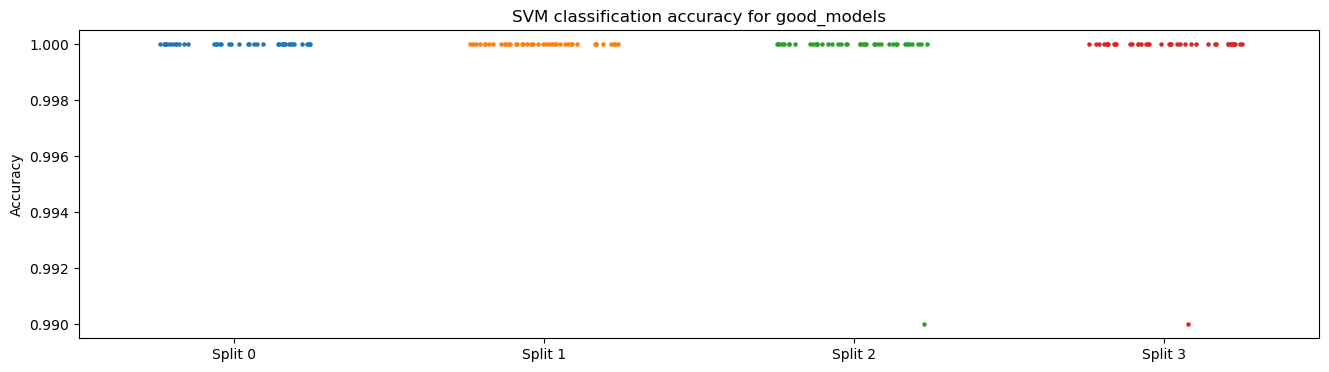

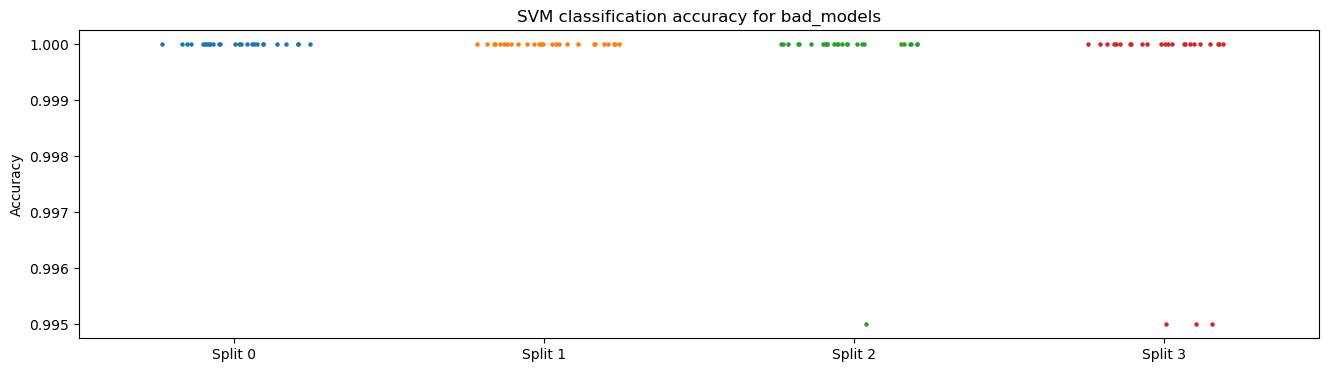

In [33]:
# plot results as scatter plot with jitter

for i, models_type in enumerate(models_types):
    plt.figure(figsize=(16, 4))
    for i_split in range(n_delay_splits):
        plt.scatter(np.ones(len(all_accs[i]))*i_split + np.random.uniform(-.25,0.25, len(all_accs[i])), all_accs[i][:,i_split], 
                    s = 5)
    plt.xticks(range(n_delay_splits), [f'Split {i}' for i in range(n_delay_splits)])
    # plt.ylim([0.9,1.1])
    plt.xlim([-0.5,n_delay_splits-0.5])
    plt.ylabel('Accuracy')
    plt.title(f'SVM classification accuracy for {models_type}')
    plt.show()
    
    

### divide delay by 10

In [43]:
# continue splitting up the delay period

importlib.reload(tu)

models_types = ['good_models','bad_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

n_delay_splits = 10
all_accs = []

for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    times = np.arange(settings['stim_on']+settings['stim_dur'],settings['stim_on']+settings['stim_dur']+settings['delay']) # Maintenance
    delay_splits = np.array_split(times, n_delay_splits)

    accs_splits = np.zeros((len(model_list),len(delay_splits)))
    for i_split, delay_idxs in enumerate(delay_splits):
        for i_model in range(len(model_list)):
            RNN_model_file = model_list[i_model]
            model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
            rnn_path = os.path.join(models_dir, RNN_model_file) 
            model_path = os.path.join(models_dir, RNN_model_file)
            model = scipy.io.loadmat(model_path)

            # get X for this model, and restrict to delay period
            xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
            delay_xx_trials = np.mean(xx_trials[:,delay_idxs,:], axis=1)

            trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')
            decode_labels = trial_stim_labels[:,0]

            # split trials into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(delay_xx_trials, decode_labels, test_size=0.2, random_state=42)

            # train SVM
            clf = SVC(kernel='rbf')
            clf.fit(X_train, y_train)

            # test SVM
            y_pred = clf.predict(X_test)
            accs_splits[i_model,i_split] = np.mean(y_pred == y_test)

    all_accs.append(accs_splits)

print(all_accs[0].shape)
print(all_accs[1].shape)





Analyzing good_models
Analyzing bad_models
(41, 10)
(26, 10)


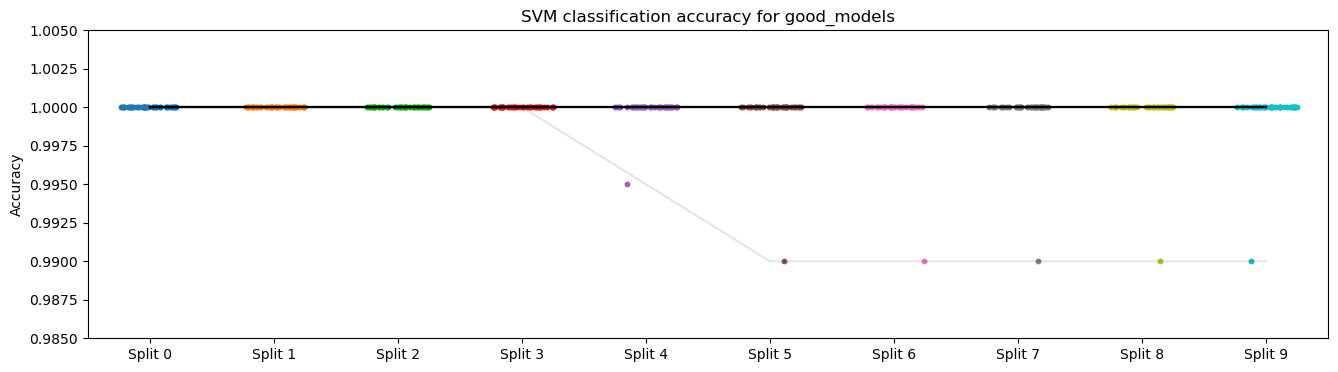

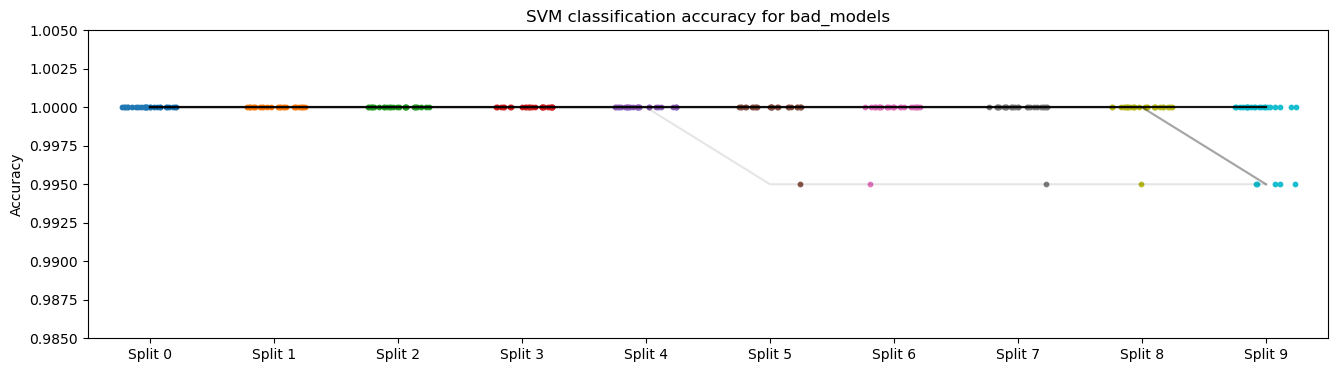

In [45]:
# plot results as scatter plot with jitter

for i, models_type in enumerate(models_types):
    plt.figure(figsize=(16, 4))
    for i_model in range(len(all_accs[i])):
        plt.plot(range(n_delay_splits), all_accs[i][i_model], color='black', alpha=0.1)
    for i_split in range(n_delay_splits):
        plt.scatter(np.ones(len(all_accs[i]))*i_split + np.random.uniform(-.25,0.25, len(all_accs[i])), all_accs[i][:,i_split], 
                    s = 10)
    plt.xticks(range(n_delay_splits), [f'Split {i}' for i in range(n_delay_splits)])
    plt.ylim([0.985,1.005])
    plt.xlim([-0.5,n_delay_splits-0.5])
    plt.ylabel('Accuracy')
    plt.title(f'SVM classification accuracy for {models_type}')
    plt.show()
    
    

### divide delay by into 25ms bins

In [4]:
# continue splitting up the delay period

importlib.reload(tu)

models_types = ['good_models','bad_models', 'lesion_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

n_bins = 30
all_accs = []

for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    if models_type == 'lesion_models':
        models_type = 'good_models'
        lesion = 'ii'
        lesion_flag = f'_lesion{lesion}'
    else:
        lesion = ''
        lesion_flag = ''

    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    times = np.arange(settings['stim_on']+settings['stim_dur'],settings['stim_on']+settings['stim_dur']+settings['delay']) # Maintenance
    time_bins = np.array_split(times, n_bins)

    accs_splits = np.zeros((len(model_list),len(time_bins)))
    for i_bin, delay_idxs in enumerate(time_bins):
        for i_model in range(len(model_list)):
            RNN_model_file = model_list[i_model]
            model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
            rnn_path = os.path.join(models_dir, RNN_model_file) 
            model_path = os.path.join(models_dir, RNN_model_file)
            model = scipy.io.loadmat(model_path)

            # get X for this model, and restrict to delay period
            xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX{lesion_flag}.npy')
            delay_xx_trials = np.mean(xx_trials[:,delay_idxs,:], axis=1)

            trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels{lesion_flag}.npy')
            decode_labels = trial_stim_labels[:,0]

            # split trials into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(delay_xx_trials, decode_labels, test_size=0.2, random_state=42)

            # train SVM
            clf = SVC(kernel='rbf')
            clf.fit(X_train, y_train)

            # test SVM
            y_pred = clf.predict(X_test)
            accs_splits[i_model,i_bin] = np.mean(y_pred == y_test)

    all_accs.append(accs_splits)

print(all_accs[0].shape)
print(all_accs[1].shape)





Analyzing good_models
Analyzing bad_models
Analyzing lesion_models
(41, 30)
(26, 30)


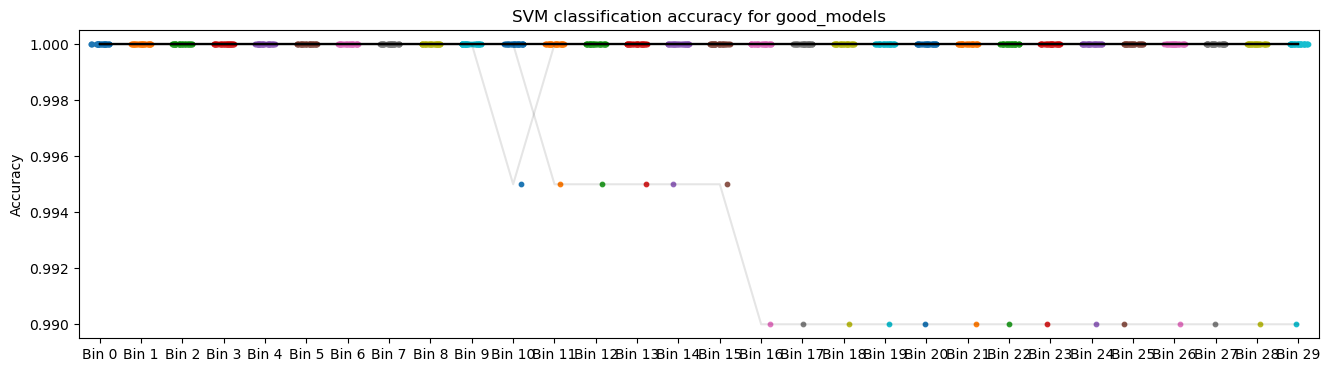

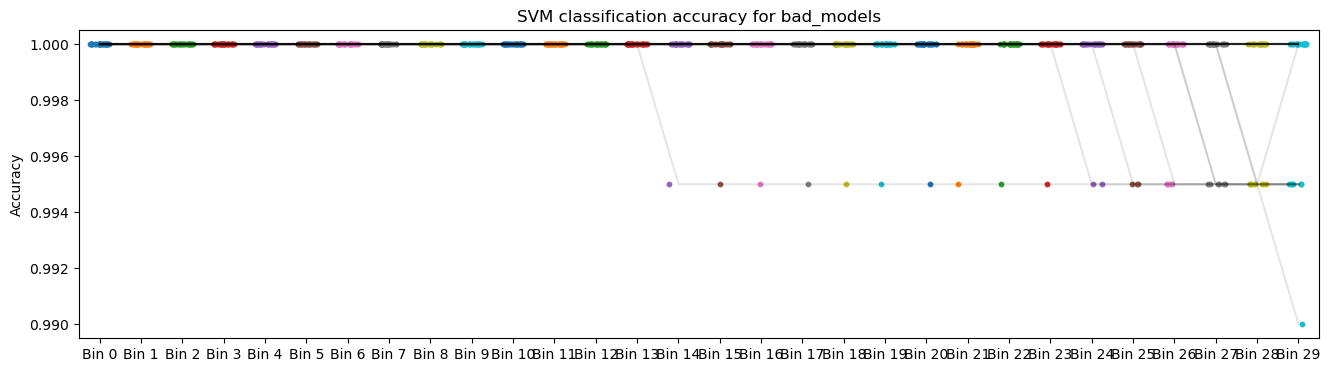

In [14]:
# plot results as scatter plot with jitter

for i, models_type in enumerate(models_types):
    plt.figure(figsize=(16, 4))
    for i_model in range(len(all_accs[i])):
        plt.plot(range(n_bins), all_accs[i][i_model], color='black', alpha=0.1)
    for i_bin in range(n_bins):
        plt.scatter(np.ones(len(all_accs[i]))*i_bin + np.random.uniform(-.25,0.25, len(all_accs[i])), all_accs[i][:,i_bin], 
                    s = 10)
    plt.xticks(range(n_bins), [f'Bin {i}' for i in range(n_bins)])
    # plt.ylim([0.985,1.005])
    plt.xlim([-0.5,n_bins-0.5])
    plt.ylabel('Accuracy')
    plt.title(f'SVM classification accuracy for {models_type}')
    plt.show()
    
    

In [5]:
# colors = ['#941834', '#4C4C4C']
colors = ['#941834', '#4C4C4C', '#D2B48C']

In [ ]:
# convert into paired boxplots (just good vs bad models)

from matplotlib.patches import Patch

plt.figure(figsize=(16, 4))
legend_handles = []


for i, models_type in enumerate(['good_models','bad_models']):
    x_positions = np.arange(n_bins)
    if i == 0:
        plt.boxplot(all_accs[i], positions= x_positions-0.2, widths=0.2, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], color=colors[i]))
    else:
        plt.boxplot(all_accs[i], positions= x_positions+0.2, widths=0.2, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], color=colors[i]))
    legend_handles.append(Patch(color=colors[i], label=models_type))

plt.xticks(range(n_bins), [int((bin[0]-settings['stim_on'] - settings['stim_dur'])/200*1000) for bin in time_bins])
# plt.ylim([0.985,1.005])
plt.xlim([-0.5,n_bins-0.5])
plt.ylabel('Accuracy')
plt.xlabel('Time during delay period (ms), relative to delay onset')
plt.title(f'SVM classification accuracy')
plt.legend(handles=legend_handles, loc='best')
plt.show()
    
    

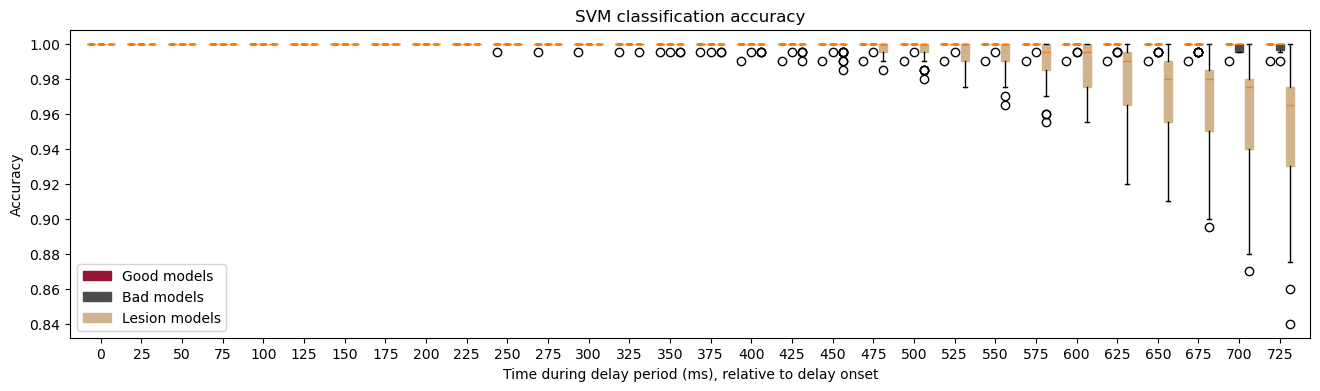

In [9]:
# convert into paired boxplots

from matplotlib.patches import Patch

plt.figure(figsize=(16, 4))
legend_handles = []

plot_sep = 0.25

for i in range(n_bins):
    # Define the boxprops to set the color
    boxprops = dict(facecolor=colors[0], color=colors[0])  # Use the first color in your list (adjust if needed)
    
    # Plot boxplots for each model type, specifying positions, widths, and box properties
    plt.boxplot([all_accs[0][:,i]], 
                positions=[i-plot_sep], 
                widths=0.2,
                patch_artist=True, 
                boxprops=boxprops)
    
    # You can modify colors dynamically if you want different colors for different boxplots:
    boxprops = dict(facecolor=colors[1], color=colors[1])  # Adjust color for the next box
    plt.boxplot([all_accs[1][:,i]], positions=[i], widths=0.2, patch_artist=True, boxprops=boxprops)
    
    boxprops = dict(facecolor=colors[2], color=colors[2])  # Adjust color for the next box
    plt.boxplot([all_accs[2][:,i]], positions=[i+plot_sep], widths=0.2, patch_artist=True, boxprops=boxprops)

    
legend_handles.append(Patch(color=colors[0], label='Good models'))
legend_handles.append(Patch(color=colors[1], label='Bad models'))
legend_handles.append(Patch(color=colors[2], label='Lesion models'))

plt.xticks(range(n_bins), [int((bin[0]-settings['stim_on'] - settings['stim_dur'])/200*1000) for bin in time_bins])
plt.ylabel('Accuracy')
plt.xlabel('Time during delay period (ms), relative to delay onset')
plt.title(f'SVM classification accuracy')
plt.legend(handles=legend_handles, loc='best')
plt.show()
    
    

### divide delay by into 25ms bins, and decode with up to that bin (accumulated signal)

In [12]:
# continue splitting up the delay period

importlib.reload(tu)

models_types = ['good_models','bad_models', 'lesion_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

n_bins = 30
all_accs = []

for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    if models_type == 'lesion_models':
        models_type = 'good_models'
        lesion = 'ii'
        lesion_flag = f'_lesion{lesion}'
    else:
        lesion = ''
        lesion_flag = ''

    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    times = np.arange(settings['stim_on']+settings['stim_dur'],settings['stim_on']+settings['stim_dur']+settings['delay']) # Maintenance
    time_bins = np.array_split(times, n_bins)
    # convert time bins into cumulative time bins
    cumulative_time_bins = [np.concatenate(time_bins[:i+1]) for i in range(len(time_bins))]

    accs_splits = np.zeros((len(model_list),len(cumulative_time_bins)))
    for i_bin, delay_idxs in enumerate(cumulative_time_bins):
        for i_model in range(len(model_list)):
            RNN_model_file = model_list[i_model]
            model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
            rnn_path = os.path.join(models_dir, RNN_model_file) 
            model_path = os.path.join(models_dir, RNN_model_file)
            model = scipy.io.loadmat(model_path)

            # get X for this model, and restrict to delay period
            xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX{lesion_flag}.npy')
            delay_xx_trials = np.mean(xx_trials[:,delay_idxs,:], axis=1)

            trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels{lesion_flag}.npy')
            decode_labels = trial_stim_labels[:,0]

            # split trials into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(delay_xx_trials, decode_labels, test_size=0.2, random_state=42)

            # train SVM
            clf = SVC(kernel='rbf')
            clf.fit(X_train, y_train)

            # test SVM
            y_pred = clf.predict(X_test)
            accs_splits[i_model,i_bin] = np.mean(y_pred == y_test)

    all_accs.append(accs_splits)

print(all_accs[0].shape)
print(all_accs[1].shape)
print(all_accs[2].shape)




Analyzing good_models
Analyzing bad_models
Analyzing lesion_models
(41, 30)
(26, 30)
(41, 30)


In [ ]:
# colors = ['#941834', '#4C4C4C']
colors = ['#941834', '#4C4C4C', '#D2B48C']

In [ ]:
# convert into paired boxplots (just good vs bad models)

from matplotlib.patches import Patch

plt.figure(figsize=(16, 4))
legend_handles = []


for i, models_type in enumerate(['good_models','bad_models']):
    x_positions = np.arange(n_bins)
    if i == 0:
        plt.boxplot(all_accs[i], positions= x_positions-0.2, widths=0.2, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], color=colors[i]))
    else:
        plt.boxplot(all_accs[i], positions= x_positions+0.2, widths=0.2, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], color=colors[i]))
    legend_handles.append(Patch(color=colors[i], label=models_type))

plt.xticks(range(n_bins), [int((bin[0]-settings['stim_on'] - settings['stim_dur'])/200*1000) for bin in time_bins])
# plt.ylim([0.985,1.005])
plt.xlim([-0.5,n_bins-0.5])
plt.ylabel('Accuracy')
plt.xlabel('Time during delay period (ms), relative to delay onset. all time bins up to this period')
plt.title(f'SVM classification accuracy')
plt.legend(handles=legend_handles, loc='best')
plt.show()
    
    

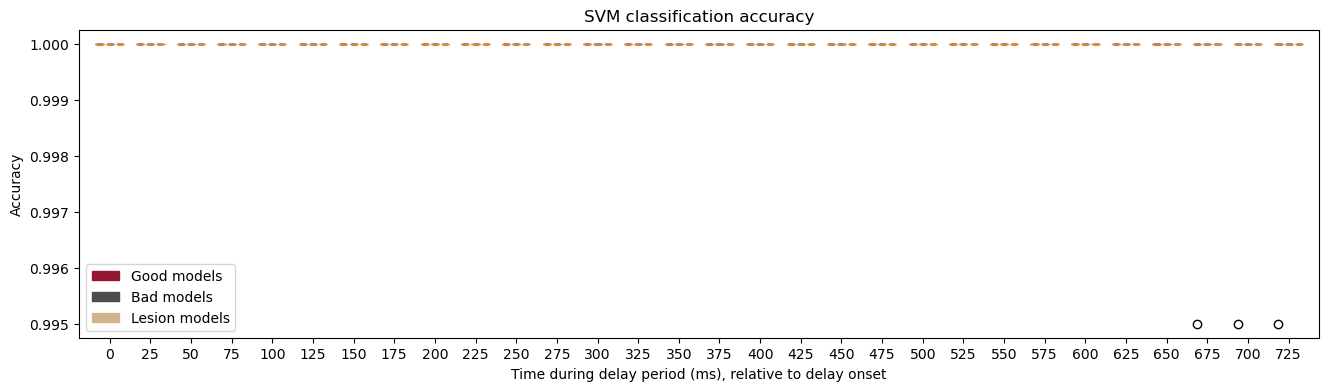

In [13]:
# ACCUMULATED SIGNAL

from matplotlib.patches import Patch

plt.figure(figsize=(16, 4))
legend_handles = []

plot_sep = 0.25

for i in range(n_bins):
    # Define the boxprops to set the color
    boxprops = dict(facecolor=colors[0], color=colors[0])  # Use the first color in your list (adjust if needed)
    
    # Plot boxplots for each model type, specifying positions, widths, and box properties
    plt.boxplot([all_accs[0][:,i]], 
                positions=[i-plot_sep], 
                widths=0.2,
                patch_artist=True, 
                boxprops=boxprops)
    
    # You can modify colors dynamically if you want different colors for different boxplots:
    boxprops = dict(facecolor=colors[1], color=colors[1])  # Adjust color for the next box
    plt.boxplot([all_accs[1][:,i]], positions=[i], widths=0.2, patch_artist=True, boxprops=boxprops)
    
    boxprops = dict(facecolor=colors[2], color=colors[2])  # Adjust color for the next box
    plt.boxplot([all_accs[2][:,i]], positions=[i+plot_sep], widths=0.2, patch_artist=True, boxprops=boxprops)

    
legend_handles.append(Patch(color=colors[0], label='Good models'))
legend_handles.append(Patch(color=colors[1], label='Bad models'))
legend_handles.append(Patch(color=colors[2], label='Lesion models'))

plt.xticks(range(n_bins), [int((bin[0]-settings['stim_on'] - settings['stim_dur'])/200*1000) for bin in time_bins])
plt.ylabel('Accuracy')
plt.xlabel('Time during delay period (ms), relative to delay onset')
plt.title(f'SVM classification accuracy')
plt.legend(handles=legend_handles, loc='best')
plt.show()
    
    

## Decode stim1 identity from stim2 period

### divide stim2 into 25ms bins

In [2]:
# continue splitting up the delay period

importlib.reload(tu)

models_types = ['good_models','bad_models', 'lesion_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

n_bins = 10
all_accs = []

for models_type in models_types:
    print(f'Analyzing {models_type}')

    if models_type == 'lesion_models':
        models_type = 'good_models'
        lesion = 'ii'
        lesion_flag = f'_lesion{lesion}'
    else:
        lesion = ''
        lesion_flag = ''
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    # times = np.arange(settings['stim_on']+settings['stim_dur'],settings['stim_on']+settings['stim_dur']+settings['delay']) # Maintenance
    # delay_splits = np.array_split(times, n_delay_splits)
    
    # get stim2 period
    times = np.arange(settings['stim_on']+settings['stim_dur']+settings['delay'],settings['stim_on']+2*settings['stim_dur']+settings['delay'])
    time_bins = np.array_split(times, n_bins)

    accs_bins = np.zeros((len(model_list),len(time_bins)))
    for i_bin, time_idxs in enumerate(time_bins):
        for i_model in range(len(model_list)):
            RNN_model_file = model_list[i_model]
            model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
            rnn_path = os.path.join(models_dir, RNN_model_file) 
            model_path = os.path.join(models_dir, RNN_model_file)
            model = scipy.io.loadmat(model_path)

            # get X for this model, and restrict to delay period
            xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX{lesion_flag}.npy')
            stim2_xx_trials = np.mean(xx_trials[:,time_idxs,:], axis=1)

            trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels{lesion_flag}.npy')
            decode_labels = trial_stim_labels[:,0]

            # split trials into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(stim2_xx_trials, decode_labels, test_size=0.2, random_state=42)

            # train SVM
            clf = SVC(kernel='rbf')
            clf.fit(X_train, y_train)

            # test SVM
            y_pred = clf.predict(X_test)
            accs_bins[i_model,i_bin] = np.mean(y_pred == y_test)

    all_accs.append(accs_bins)

print(all_accs[0].shape)
print(all_accs[1].shape)
print(all_accs[2].shape)




Analyzing good_models
Analyzing bad_models
Analyzing lesion_models
(41, 10)
(26, 10)
(41, 10)


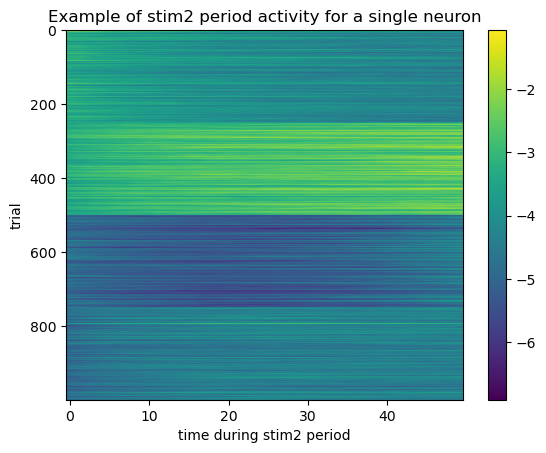

In [17]:
plt.imshow(xx_trials[:,times,0], aspect='auto')
plt.xlabel('time during stim2 period')
plt.ylabel('trial')
plt.title('Example of stim2 period activity for a single neuron')
plt.colorbar()
plt.show()

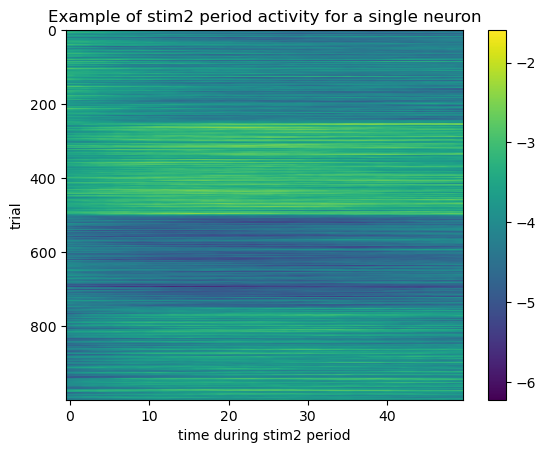

In [17]:
plt.imshow(xx_trials[:,times,0], aspect='auto')
plt.xlabel('time during stim2 period')
plt.ylabel('trial')
plt.title('Example of stim2 period activity for a single neuron')
plt.colorbar()
plt.show()

In [7]:
# colors = ['#941834', '#4C4C4C']
colors = ['#007A7A', '#7A007A', '#C0543C']

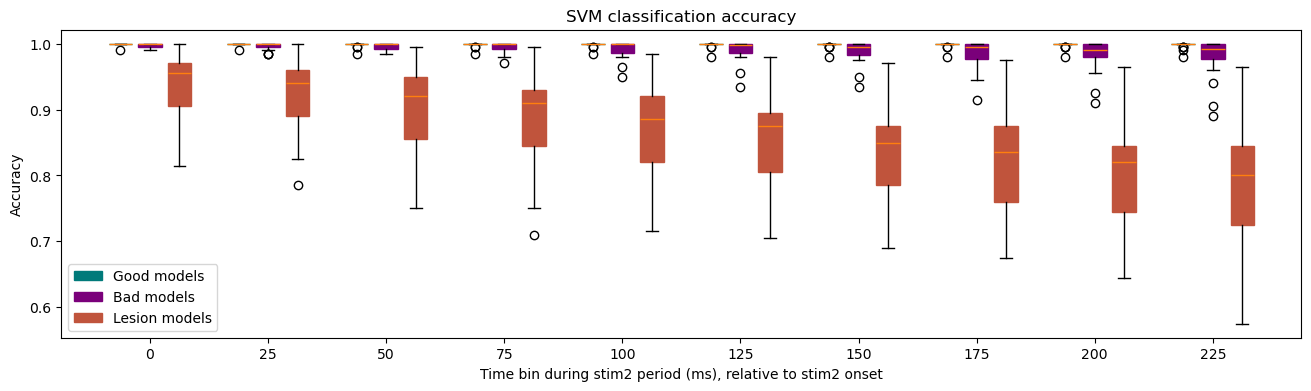

In [8]:
# convert into paired boxplots

from matplotlib.patches import Patch

plt.figure(figsize=(16, 4))
legend_handles = []

plot_sep = 0.25

for i in range(n_bins):
    # Define the boxprops to set the color
    boxprops = dict(facecolor=colors[0], color=colors[0])  # Use the first color in your list (adjust if needed)
    
    # Plot boxplots for each model type, specifying positions, widths, and box properties
    plt.boxplot([all_accs[0][:,i]], 
                positions=[i-plot_sep], 
                widths=0.2,
                patch_artist=True, 
                boxprops=boxprops)
    
    # You can modify colors dynamically if you want different colors for different boxplots:
    boxprops = dict(facecolor=colors[1], color=colors[1])  # Adjust color for the next box
    plt.boxplot([all_accs[1][:,i]], positions=[i], widths=0.2, patch_artist=True, boxprops=boxprops)
    
    boxprops = dict(facecolor=colors[2], color=colors[2])  # Adjust color for the next box
    plt.boxplot([all_accs[2][:,i]], positions=[i+plot_sep], widths=0.2, patch_artist=True, boxprops=boxprops)

    
legend_handles.append(Patch(color=colors[0], label='Good models'))
legend_handles.append(Patch(color=colors[1], label='Bad models'))
legend_handles.append(Patch(color=colors[2], label='Lesion models'))

plt.xticks(range(n_bins), [int((bin[0]-settings['stim_on'] - settings['stim_dur'] - settings['delay'])/200*1000) for bin in time_bins])
plt.ylabel('Accuracy')
plt.xlabel('Time bin during stim2 period (ms), relative to stim2 onset')
plt.title(f'SVM classification accuracy')
plt.legend(handles=legend_handles, loc='best')

# save fig as svg
plt.savefig('/home/nuttidalab/Documents/spikeRNN/results/2025_Cosyne/Poster/decoding_stim2_period.svg', format='svg')

plt.show()
    

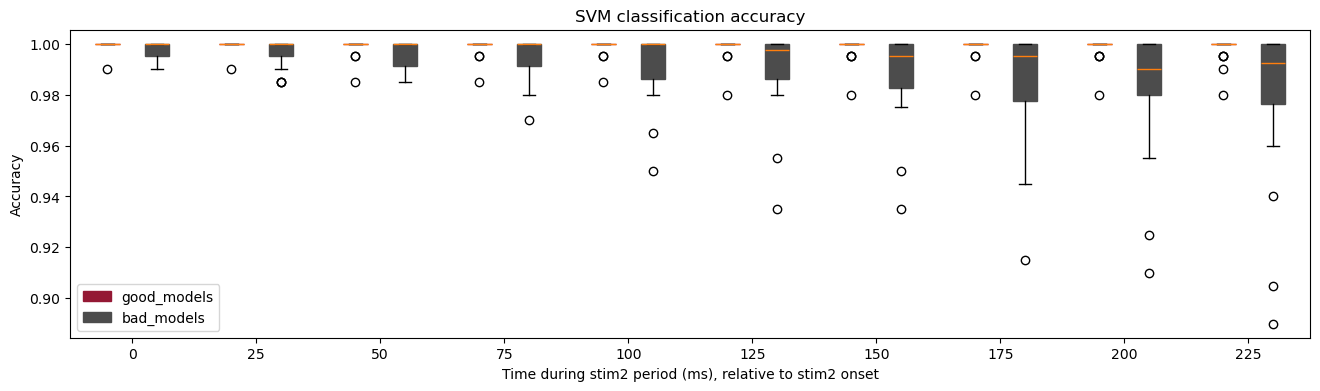

In [12]:
# convert into paired boxplots

from matplotlib.patches import Patch

n_bins = 10
time_bins = np.array_split(times, n_bins)

plt.figure(figsize=(16, 4))
legend_handles = []
for i, models_type in enumerate(models_types):
    x_positions = np.arange(n_bins)
    if i == 0:
        plt.boxplot(all_accs[i], positions= x_positions-0.2, widths=0.2, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], color=colors[i]))
    else:
        plt.boxplot(all_accs[i], positions= x_positions+0.2, widths=0.2, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], color=colors[i]))
    legend_handles.append(Patch(color=colors[i], label=models_type))

plt.xticks(range(n_bins), [int((bin[0]-settings['stim_on'] - settings['stim_dur'] - settings['delay'])/200*1000) for bin in time_bins])
# plt.ylim([0.985,1.005])
plt.xlim([-0.5,n_bins-0.5])
plt.ylabel('Accuracy')
plt.xlabel('Time during stim2 period (ms), relative to stim2 onset')
plt.title(f'SVM classification accuracy')
plt.legend(handles=legend_handles, loc='best')
plt.show()
    
    